In [1]:
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [3]:
import medmnist
from medmnist import INFO, Evaluator

In [4]:
# Import local files
%load_ext autoreload
%autoreload 2
from training import *
from plots import *
from cnn import *
from constants import *

In [5]:
data_flag = 'dermamnist'
download = True

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

In [6]:
info

{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

In [7]:
# Note: this preprocesses data such that it has mean 0.5 and std dev 0.5.
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5], std=[.5])
])

# load the data
train_dataset = DataClass(split='train', transform=data_transform, download=download)
val_dataset = DataClass(split='val', transform=data_transform, download=download)
test_dataset = DataClass(split='test', transform=data_transform, download=download)

BATCH_SIZE = 128

# encapsulate data into dataloader form
train_loader = data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
# train_loader_at_eval = data.DataLoader(dataset=train_dataset, batch_size=2*BATCH_SIZE, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=2*BATCH_SIZE, shuffle=False)

In [8]:
def default_setup(lr=0.001, l2_weight=0.0):
    model = CNN(n_channels, n_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_weight)
    return model, criterion, optimizer

## Fully Labeled Dataset
What kind of performance can we get if we leave all labels in the dataset?
This might be helpful just to view as an upper bound, like our best possible performance

In [ ]:
cnn_labeled, criterion, optimizer = default_setup()

train_history = train_loop_labeled(cnn_labeled, train_loader, val_loader, criterion, optimizer, num_epochs=20)

100%|██████████| 55/55 [00:04<00:00, 13.24it/s]


Epoch 1/20 | Train Loss: 0.9465 | Val Loss: 0.8208 | Val Acc: 0.6830 | Val AUC: 0.8794


100%|██████████| 55/55 [00:04<00:00, 13.41it/s]


Epoch 2/20 | Train Loss: 0.7975 | Val Loss: 0.7750 | Val Acc: 0.7149 | Val AUC: 0.8881


100%|██████████| 55/55 [00:04<00:00, 13.38it/s]


...

Epoch 18/20 | Train Loss: 0.3337 | Val Loss: 0.8703 | Val Acc: 0.7438 | Val AUC: 0.9099


100%|██████████| 55/55 [00:04<00:00, 13.30it/s]


Epoch 19/20 | Train Loss: 0.2974 | Val Loss: 0.8180 | Val Acc: 0.7458 | Val AUC: 0.9162


100%|██████████| 55/55 [00:04<00:00, 13.21it/s]


Epoch 20/20 | Train Loss: 0.2413 | Val Loss: 0.9594 | Val Acc: 0.7328 | Val AUC: 0.9057


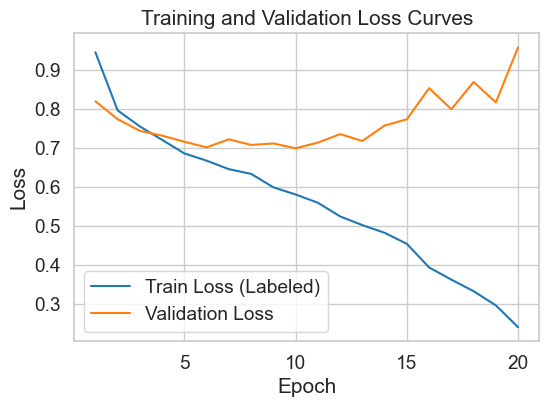

In [11]:
plot_loss_curves(train_history)

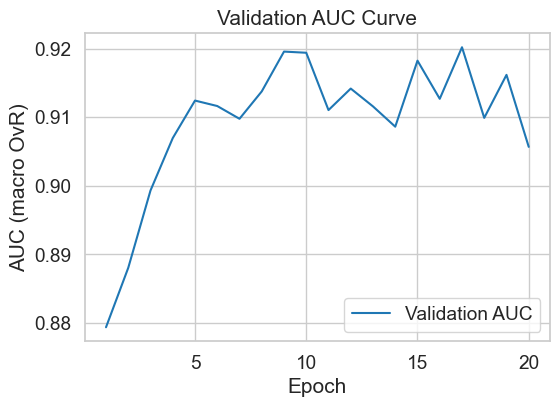

In [13]:
plot_auc_curve(train_history)

In [15]:
best = max(train_history, key=lambda x: x['val_auc'])
print(f"Best Epoch: {best['epoch']} | Val AUC: {best['val_auc']:.4f} | Val Acc: {best['val_acc']:.4f}")

best_model_upper_bound = CNN(n_channels, n_classes)
best_model_upper_bound.load_state_dict(best['model_state'])

Best Epoch: 17 | Val AUC: 0.9202 | Val Acc: 0.7488


<All keys matched successfully>

In [17]:
test_auc = evaluate(best_model_upper_bound, test_loader)
print(f"Test AUC: {test_auc:.4f}")

Test AUC: 0.9116


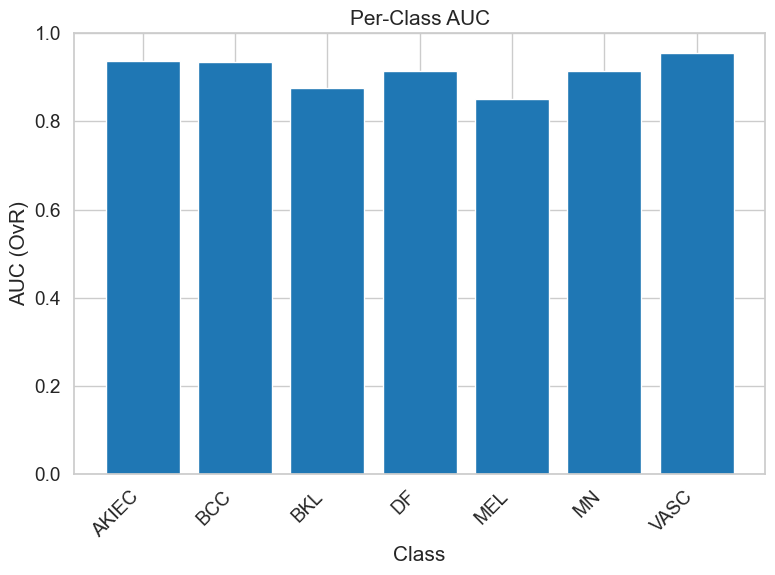

In [30]:
perclass_auc, confusion_matrix = evaluate_perclass(best_model_upper_bound, test_loader)
plot_perclass_auc(perclass_auc, list(short_labels.values()))

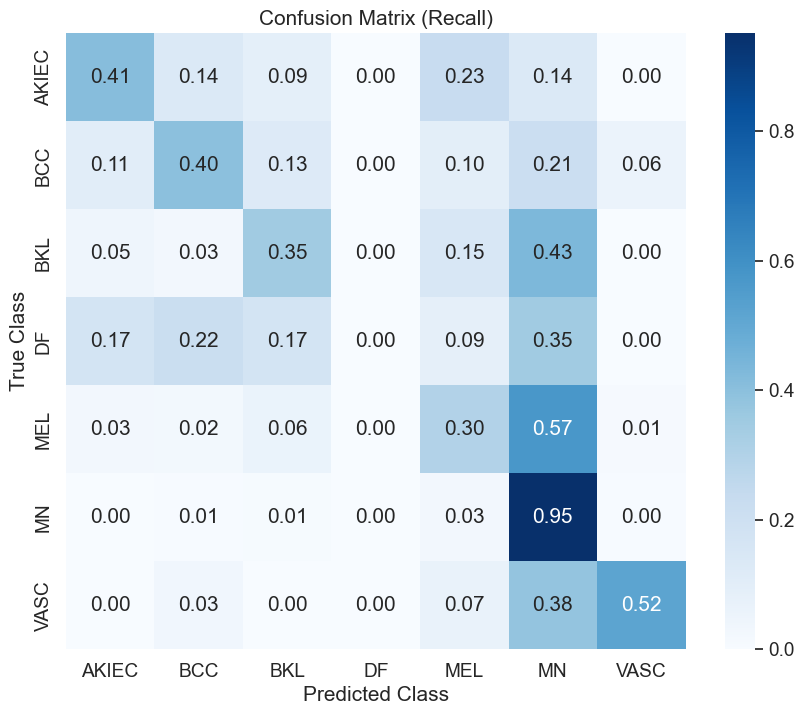

In [32]:
plot_per_class_recall(confusion_matrix, list(short_labels.values()))

## Create SSL versions of the dataset - start with 50% unlabeled rate

In [10]:
RANDOM_SEED = 42

In [12]:
# Create SSL versions of our datasets
unlabeled_rate = 0.5

# print(train_dataset.labels)
# print(train_dataset.imgs)
train_labels_ssl_50 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_50 = SSLDataset(train_dataset, train_labels_ssl_50)
train_ssl_loader_50 = data.DataLoader(train_ssl_dataset_50, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.5 | Total examples: 7007 | Labeled examples: 3506 | Unlabeled examples: 3501
Class 0: 114/228 labeled, 114 unlabeled
Class 1: 180/359 labeled, 179 unlabeled
Class 2: 385/769 labeled, 384 unlabeled
Class 3: 40/80 labeled, 40 unlabeled
Class 4: 390/779 labeled, 389 unlabeled
Class 5: 2347/4693 labeled, 2346 unlabeled
Class 6: 50/99 labeled, 49 unlabeled


### Baseline non-Bayesian CNN

In [ ]:
ssl_model_50, criterion, optimizer = default_setup()
ssl_history_50 = train_loop_hard_pseudo_label(ssl_model_50, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=20)

100%|██████████| 55/55 [00:04<00:00, 13.13it/s]


Epoch 1/20 | Train Loss Labeled: 0.9817 | Train Loss Unlabeled: 0.0125 | Val Loss: 0.8882 | Val Acc: 0.6800 | Val AUC: 0.8394


100%|██████████| 55/55 [00:04<00:00, 12.93it/s]


Epoch 2/20 | Train Loss Labeled: 0.8491 | Train Loss Unlabeled: 0.0094 | Val Loss: 0.8272 | Val Acc: 0.6899 | Val AUC: 0.8679


100%|██████████| 55/55 [00:04<00:00, 12.82it/s]


...

Epoch 18/20 | Train Loss Labeled: 0.4456 | Train Loss Unlabeled: 0.0068 | Val Loss: 0.8168 | Val Acc: 0.7218 | Val AUC: 0.9096


100%|██████████| 55/55 [00:04<00:00, 12.85it/s]


Epoch 19/20 | Train Loss Labeled: 0.4342 | Train Loss Unlabeled: 0.0068 | Val Loss: 0.7969 | Val Acc: 0.7308 | Val AUC: 0.9102


100%|██████████| 55/55 [00:04<00:00, 12.75it/s]


Epoch 20/20 | Train Loss Labeled: 0.3819 | Train Loss Unlabeled: 0.0073 | Val Loss: 0.8827 | Val Acc: 0.7278 | Val AUC: 0.9016


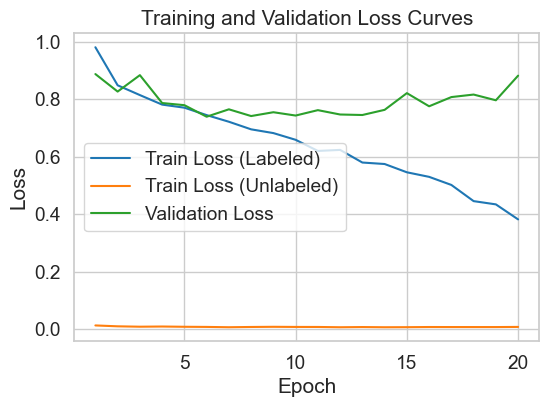

In [ ]:
plot_loss_curves(ssl_history, use_unlabeled=True, unlabeled_rate=unlabeled_rate)

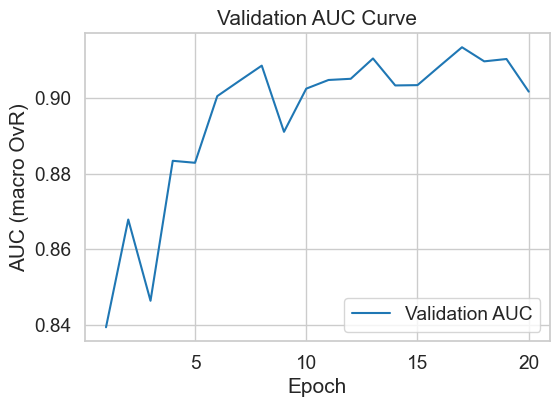

In [ ]:
plot_auc_curve(ssl_history, unlabeled_rate=unlabeled_rate)

In [72]:
best_ssl_history = max(ssl_history, key=lambda x: x['val_auc'])
print(f"Best Epoch: {best_ssl_history['epoch']} | Val AUC: {best_ssl_history['val_auc']:.4f} | Val Acc: {best_ssl_history['val_acc']:.4f}")

best_ssl_model = CNN(n_channels, n_classes)
best_ssl_model.load_state_dict(best_ssl_history['model_state'])

Best Epoch: 17 | Val AUC: 0.9134 | Val Acc: 0.7378


<All keys matched successfully>

In [73]:
test_auc = evaluate(best_ssl_model, test_loader)
print(f"Test AUC: {test_auc:.4f}")

Test AUC: 0.8975


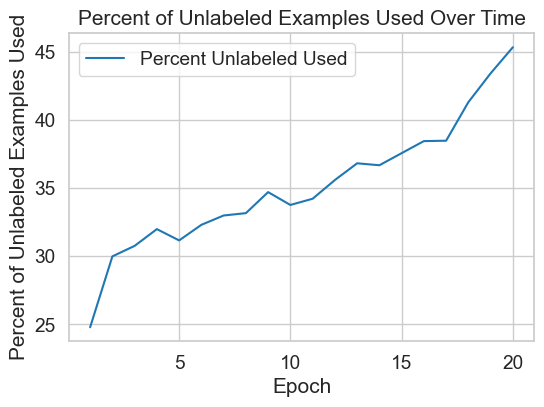

In [75]:
plot_percent_unlabeled_used(ssl_history)

### Trying 75% unlabeled rate

In [15]:
# Create SSL versions of our datasets
unlabeled_rate = 0.75

train_labels_ssl_75 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_75 = SSLDataset(train_dataset, train_labels_ssl_75)
train_ssl_loader_75 = data.DataLoader(train_ssl_dataset_75, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.75 | Total examples: 7007 | Labeled examples: 1754 | Unlabeled examples: 5253
Class 0: 57/228 labeled, 171 unlabeled
Class 1: 90/359 labeled, 269 unlabeled
Class 2: 193/769 labeled, 576 unlabeled
Class 3: 20/80 labeled, 60 unlabeled
Class 4: 195/779 labeled, 584 unlabeled
Class 5: 1174/4693 labeled, 3519 unlabeled
Class 6: 25/99 labeled, 74 unlabeled


In [90]:
ssl_model_75, criterion, optimizer = default_setup()
ssl_history_75 = train_loop_hard_pseudo_label(ssl_model_75, train_ssl_loader_75, val_loader, criterion, optimizer, num_epochs=20)

100%|██████████| 55/55 [00:04<00:00, 13.17it/s]


Epoch 1/20 | Train Loss Labeled: 1.0122 | Train Loss Unlabeled: 0.0135 | Val Loss: 0.8711 | Val Acc: 0.6670 | Val AUC: 0.8388


100%|██████████| 55/55 [00:04<00:00, 12.96it/s]


Epoch 2/20 | Train Loss Labeled: 0.8839 | Train Loss Unlabeled: 0.0097 | Val Loss: 0.8735 | Val Acc: 0.6730 | Val AUC: 0.8529


100%|██████████| 55/55 [00:04<00:00, 12.92it/s]


...

Epoch 18/20 | Train Loss Labeled: 0.5151 | Train Loss Unlabeled: 0.0076 | Val Loss: 0.8824 | Val Acc: 0.7019 | Val AUC: 0.8712


100%|██████████| 55/55 [00:04<00:00, 12.58it/s]


Epoch 19/20 | Train Loss Labeled: 0.4741 | Train Loss Unlabeled: 0.0073 | Val Loss: 0.8732 | Val Acc: 0.7039 | Val AUC: 0.8814


100%|██████████| 55/55 [00:04<00:00, 12.84it/s]


Epoch 20/20 | Train Loss Labeled: 0.4377 | Train Loss Unlabeled: 0.0073 | Val Loss: 0.9363 | Val Acc: 0.6899 | Val AUC: 0.8753


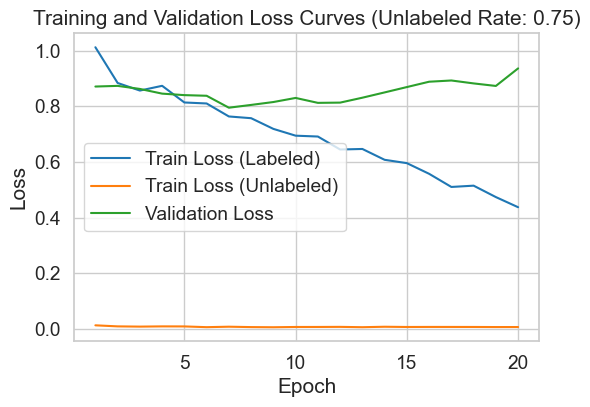

In [92]:
plot_loss_curves(ssl_history_75, use_unlabeled=True, unlabeled_rate=unlabeled_rate)

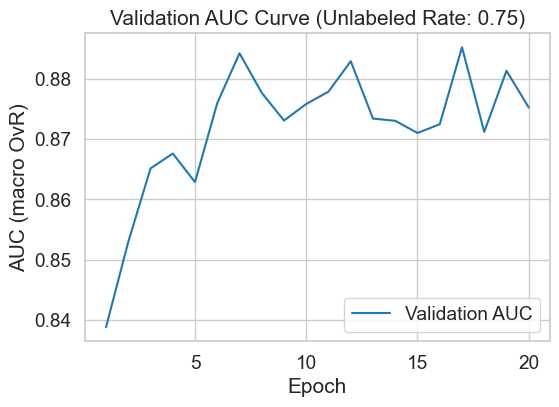

In [93]:
plot_auc_curve(ssl_history_75, unlabeled_rate=unlabeled_rate)

In [94]:
best_ssl_history_75 = max(ssl_history_75, key=lambda x: x['val_auc'])
print(f"Best Epoch: {best_ssl_history_75['epoch']} | Val AUC: {best_ssl_history_75['val_auc']:.4f} | Val Acc: {best_ssl_history_75['val_acc']:.4f}")

best_ssl_model_75 = CNN(n_channels, n_classes)
best_ssl_model_75.load_state_dict(best_ssl_history_75['model_state'])

Best Epoch: 17 | Val AUC: 0.8853 | Val Acc: 0.6939


<All keys matched successfully>

In [95]:
test_auc = evaluate(best_ssl_model_75, test_loader)
print(f"Test AUC: {test_auc:.4f}")

Test AUC: 0.8666


### 90%

In [24]:
# Create SSL versions of our datasets
unlabeled_rate = 0.9

train_labels_ssl_90 = get_semi_supervised_labels(train_dataset, unlabeled_rate=unlabeled_rate, seed=RANDOM_SEED)
train_ssl_dataset_90 = SSLDataset(train_dataset, train_labels_ssl_90)
train_ssl_loader_90 = data.DataLoader(train_ssl_dataset_90, batch_size=BATCH_SIZE, shuffle=True)

Unlabeled rate: 0.9 | Total examples: 7007 | Labeled examples: 702 | Unlabeled examples: 6305
Class 0: 23/228 labeled, 205 unlabeled
Class 1: 36/359 labeled, 323 unlabeled
Class 2: 77/769 labeled, 692 unlabeled
Class 3: 8/80 labeled, 72 unlabeled
Class 4: 78/779 labeled, 701 unlabeled
Class 5: 470/4693 labeled, 4223 unlabeled
Class 6: 10/99 labeled, 89 unlabeled


In [77]:
ssl_model_90, criterion, optimizer = default_setup()
ssl_history_90 = train_loop_hard_pseudo_label(ssl_model_90, train_ssl_loader_90, val_loader, criterion, optimizer, num_epochs=20)

100%|██████████| 55/55 [00:03<00:00, 14.21it/s]


Epoch 1/20 | Train Loss Labeled: 1.1600 | Train Loss Unlabeled: 0.0195 | Val Loss: 1.0121 | Val Acc: 0.6690 | Val AUC: 0.7996


100%|██████████| 55/55 [00:04<00:00, 13.66it/s]


Epoch 2/20 | Train Loss Labeled: 1.0162 | Train Loss Unlabeled: 0.0149 | Val Loss: 0.9307 | Val Acc: 0.6680 | Val AUC: 0.8393


100%|██████████| 55/55 [00:03<00:00, 13.75it/s]


...

Epoch 18/20 | Train Loss Labeled: 0.5590 | Train Loss Unlabeled: 0.0110 | Val Loss: 1.0241 | Val Acc: 0.6760 | Val AUC: 0.8353


100%|██████████| 55/55 [00:04<00:00, 13.41it/s]


Epoch 19/20 | Train Loss Labeled: 0.5807 | Train Loss Unlabeled: 0.0111 | Val Loss: 1.0700 | Val Acc: 0.6720 | Val AUC: 0.8221


100%|██████████| 55/55 [00:04<00:00, 13.47it/s]


Epoch 20/20 | Train Loss Labeled: 0.5582 | Train Loss Unlabeled: 0.0134 | Val Loss: 1.1291 | Val Acc: 0.6790 | Val AUC: 0.8341


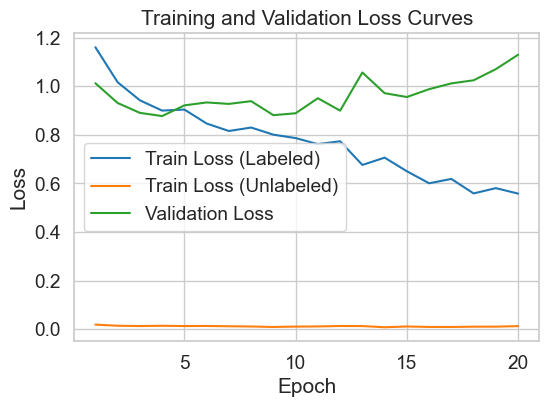

In [78]:
plot_loss_curves(ssl_history_90, use_unlabeled=True)

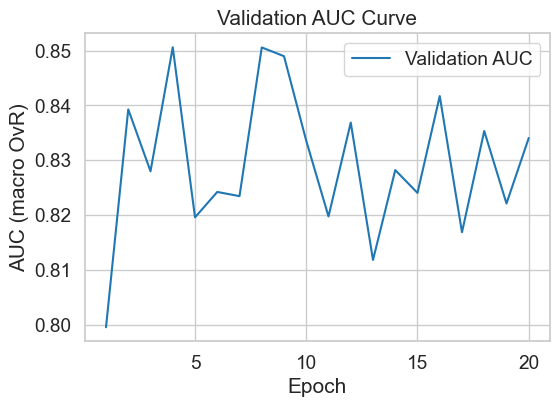

In [79]:
plot_auc_curve(ssl_history_90)

In [ ]:
best_ssl_history_90 = max(ssl_history_90, key=lambda x: x['val_auc'])
print(f"Best Epoch: {best_ssl_history_90['epoch']} | Val AUC: {best_ssl_history_90['val_auc']:.4f} | Val Acc: {best_ssl_history_90['val_acc']:.4f}")

best_ssl_model_90 = CNN(n_channels, n_classes)
best_ssl_model_90.load_state_dict(best_ssl_history_90['model_state'])

Best Epoch: 4 | Val AUC: 0.8506 | Val Acc: 0.6899


<All keys matched successfully>

In [81]:
test_auc = evaluate(best_ssl_model_90, test_loader)
print(f"Test AUC: {test_auc:.4f}")

Test AUC: 0.8325


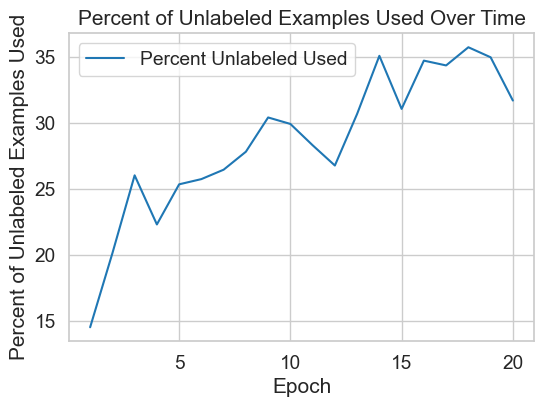

In [82]:
plot_percent_unlabeled_used(ssl_history_90)

## Hyperparameter Tuning
- We evaluate two hyperparameters via grid search: the learning rate, and the L2 penalty weight


In [16]:
# use the 75% unlabeled rate for hyperparam tuning
lr_values = [0.01, 0.001, 0.0001]
l2_pen_values = [0.0, 1e-4, 1e-3, 1e-2]

results = []
for lr in lr_values:
    for l2_pen in l2_pen_values:
        print(f'Training with lr={lr} and l2_pen={l2_pen}')
        ssl_model_75_tuning, criterion, optimizer = default_setup(lr=lr, l2_weight=l2_pen)
        ssl_history_75_tuning = train_loop_hard_pseudo_label(ssl_model_75_tuning, train_ssl_loader_75, val_loader, criterion, optimizer, num_epochs=20)
        best_ssl_history_75_tuning = max(ssl_history_75_tuning, key=lambda x: x['val_auc'])
        results.append({
            'lr': lr,
            'l2_pen': l2_pen,
            'output': best_ssl_history_75_tuning,
        })

Training with lr=0.01 and l2_pen=0.0


100%|██████████| 55/55 [00:04<00:00, 12.91it/s]


Epoch 1/20 | Train Loss Labeled: 1.1414 | Train Loss Unlabeled: 0.0102 | Val Loss: 1.4090 | Val Acc: 0.6690 | Val AUC: 0.7656


100%|██████████| 55/55 [00:04<00:00, 12.86it/s]


Epoch 2/20 | Train Loss Labeled: 0.9910 | Train Loss Unlabeled: 0.0114 | Val Loss: 0.9476 | Val Acc: 0.6510 | Val AUC: 0.8161


...

Epoch 18/20 | Train Loss Labeled: 0.3457 | Train Loss Unlabeled: 0.0092 | Val Loss: 0.8332 | Val Acc: 0.7099 | Val AUC: 0.8937


100%|██████████| 55/55 [00:04<00:00, 12.55it/s]


Epoch 19/20 | Train Loss Labeled: 0.2970 | Train Loss Unlabeled: 0.0084 | Val Loss: 0.9221 | Val Acc: 0.7119 | Val AUC: 0.8827


100%|██████████| 55/55 [00:04<00:00, 12.69it/s]


Epoch 20/20 | Train Loss Labeled: 0.2783 | Train Loss Unlabeled: 0.0094 | Val Loss: 0.8787 | Val Acc: 0.7208 | Val AUC: 0.8908


In [23]:
best_hyperparam_combination = max(results, key=lambda x: x['output']['val_auc'])
sortedResults = sorted(results, key=lambda x: x['output']['val_auc'], reverse=True)
for result in sortedResults:
    print(f"lr: {result['lr']}, l2_pen: {result['l2_pen']}, val_auc: {result['output']['val_auc']:.4f}")

lr: 0.0001, l2_pen: 0.0, val_auc: 0.9096
lr: 0.0001, l2_pen: 0.001, val_auc: 0.9004
lr: 0.0001, l2_pen: 0.0001, val_auc: 0.9000
lr: 0.0001, l2_pen: 0.01, val_auc: 0.8989
lr: 0.001, l2_pen: 0.001, val_auc: 0.8864
lr: 0.001, l2_pen: 0.0, val_auc: 0.8847
lr: 0.001, l2_pen: 0.0001, val_auc: 0.8826
lr: 0.001, l2_pen: 0.01, val_auc: 0.8780
lr: 0.01, l2_pen: 0.0, val_auc: 0.8656
lr: 0.01, l2_pen: 0.0001, val_auc: 0.8607
lr: 0.01, l2_pen: 0.001, val_auc: 0.8420
lr: 0.01, l2_pen: 0.01, val_auc: 0.8411


### Trying at 90%

In [25]:
# use the 90% unlabeled rate for hyperparam tuning
lr_values = [0.01, 0.001, 0.0001]
l2_pen_values = [0.0, 1e-4, 1e-3, 1e-2]

results = []
for lr in lr_values:
    for l2_pen in l2_pen_values:
        print(f'Training with lr={lr} and l2_pen={l2_pen}')
        ssl_model_90_tuning, criterion, optimizer = default_setup(lr=lr, l2_weight=l2_pen)
        ssl_history_90_tuning = train_loop_hard_pseudo_label(ssl_model_90_tuning, train_ssl_loader_90, val_loader, criterion, optimizer, num_epochs=20)
        best_ssl_history_90_tuning = max(ssl_history_90_tuning, key=lambda x: x['val_auc'])
        results.append({
            'lr': lr,
            'l2_pen': l2_pen,
            'output': best_ssl_history_90_tuning,
        })

Training with lr=0.01 and l2_pen=0.0


100%|██████████| 55/55 [00:04<00:00, 13.33it/s]


Epoch 1/20 | Train Loss Labeled: 1.2048 | Train Loss Unlabeled: 0.0100 | Val Loss: 1.3736 | Val Acc: 0.6690 | Val AUC: 0.7376


100%|██████████| 55/55 [00:03<00:00, 14.24it/s]


Epoch 2/20 | Train Loss Labeled: 1.1870 | Train Loss Unlabeled: 0.0118 | Val Loss: 1.0480 | Val Acc: 0.6690 | Val AUC: 0.7737


...

Epoch 18/20 | Train Loss Labeled: 0.2223 | Train Loss Unlabeled: 0.0105 | Val Loss: 0.9330 | Val Acc: 0.6969 | Val AUC: 0.8662


100%|██████████| 55/55 [00:04<00:00, 12.92it/s]


Epoch 19/20 | Train Loss Labeled: 0.1848 | Train Loss Unlabeled: 0.0098 | Val Loss: 0.9640 | Val Acc: 0.6899 | Val AUC: 0.8638


100%|██████████| 55/55 [00:04<00:00, 12.48it/s]


Epoch 20/20 | Train Loss Labeled: 0.1683 | Train Loss Unlabeled: 0.0088 | Val Loss: 0.9916 | Val Acc: 0.6849 | Val AUC: 0.8628


In [26]:
best_hyperparam_combination_90 = max(results, key=lambda x: x['output']['val_auc'])
sortedResults_90 = sorted(results, key=lambda x: x['output']['val_auc'], reverse=True)
for result in sortedResults_90:
    print(f"lr: {result['lr']}, l2_pen: {result['l2_pen']}, val_auc: {result['output']['val_auc']:.4f}")

lr: 0.0001, l2_pen: 0.0, val_auc: 0.8787
lr: 0.0001, l2_pen: 0.01, val_auc: 0.8774
lr: 0.0001, l2_pen: 0.001, val_auc: 0.8721
lr: 0.001, l2_pen: 0.0, val_auc: 0.8716
lr: 0.0001, l2_pen: 0.0001, val_auc: 0.8677
lr: 0.001, l2_pen: 0.001, val_auc: 0.8604
lr: 0.001, l2_pen: 0.01, val_auc: 0.8583
lr: 0.001, l2_pen: 0.0001, val_auc: 0.8557
lr: 0.01, l2_pen: 0.0, val_auc: 0.8402
lr: 0.01, l2_pen: 0.0001, val_auc: 0.8158
lr: 0.01, l2_pen: 0.001, val_auc: 0.8051
lr: 0.01, l2_pen: 0.01, val_auc: 0.7642


### Try 50% too

In [27]:
# use the 50% unlabeled rate for hyperparam tuning
lr_values = [0.01, 0.001, 0.0001]
l2_pen_values = [0.0, 1e-4, 1e-3, 1e-2]

results_50 = []
for lr in lr_values:
    for l2_pen in l2_pen_values:
        print(f'Training with lr={lr} and l2_pen={l2_pen}')
        ssl_model_50_tuning, criterion, optimizer = default_setup(lr=lr, l2_weight=l2_pen)
        ssl_history_50_tuning = train_loop_hard_pseudo_label(ssl_model_50_tuning, train_ssl_loader_50, val_loader, criterion, optimizer, num_epochs=20)
        best_ssl_history_50_tuning = max(ssl_history_50_tuning, key=lambda x: x['val_auc'])
        results_50.append({
            'lr': lr,
            'l2_pen': l2_pen,
            'output': best_ssl_history_50_tuning,
        })

Training with lr=0.01 and l2_pen=0.0


100%|██████████| 55/55 [00:04<00:00, 12.99it/s]


Epoch 1/20 | Train Loss Labeled: 1.1547 | Train Loss Unlabeled: 0.0099 | Val Loss: 0.9879 | Val Acc: 0.6461 | Val AUC: 0.8127


100%|██████████| 55/55 [00:04<00:00, 12.97it/s]


Epoch 2/20 | Train Loss Labeled: 0.9128 | Train Loss Unlabeled: 0.0091 | Val Loss: 0.9088 | Val Acc: 0.6730 | Val AUC: 0.8237


...

Epoch 18/20 | Train Loss Labeled: 0.3371 | Train Loss Unlabeled: 0.0094 | Val Loss: 0.7644 | Val Acc: 0.7488 | Val AUC: 0.9089


100%|██████████| 55/55 [00:04<00:00, 12.51it/s]


Epoch 19/20 | Train Loss Labeled: 0.3097 | Train Loss Unlabeled: 0.0087 | Val Loss: 0.7928 | Val Acc: 0.7388 | Val AUC: 0.9037


100%|██████████| 55/55 [00:04<00:00, 12.53it/s]


Epoch 20/20 | Train Loss Labeled: 0.2995 | Train Loss Unlabeled: 0.0082 | Val Loss: 0.7505 | Val Acc: 0.7597 | Val AUC: 0.9122


In [28]:
best_hyperparam_combination_50 = max(results_50, key=lambda x: x['output']['val_auc'])
sortedResults_50 = sorted(results_50, key=lambda x: x['output']['val_auc'], reverse=True)
for result in sortedResults_50:
    print(f"lr: {result['lr']}, l2_pen: {result['l2_pen']}, val_auc: {result['output']['val_auc']:.4f}")

lr: 0.0001, l2_pen: 0.01, val_auc: 0.9159
lr: 0.001, l2_pen: 0.001, val_auc: 0.9150
lr: 0.001, l2_pen: 0.0, val_auc: 0.9145
lr: 0.001, l2_pen: 0.01, val_auc: 0.9144
lr: 0.001, l2_pen: 0.0001, val_auc: 0.9140
lr: 0.0001, l2_pen: 0.001, val_auc: 0.9137
lr: 0.0001, l2_pen: 0.0, val_auc: 0.9130
lr: 0.0001, l2_pen: 0.0001, val_auc: 0.9125
lr: 0.01, l2_pen: 0.0001, val_auc: 0.8876
lr: 0.01, l2_pen: 0.0, val_auc: 0.8825
lr: 0.01, l2_pen: 0.001, val_auc: 0.8674
lr: 0.01, l2_pen: 0.01, val_auc: 0.8426


## Test: Does burn-in using only labeled data help?

In [29]:
# First try without burn-in
ssl_model_75_nb, criterion, optimizer = default_setup(lr=0.0001, l2_weight=0.0)
ssl_history_75_nb = train_loop_hard_pseudo_label(ssl_model_75_nb, train_ssl_loader_75, val_loader, criterion, optimizer, num_epochs=20)

100%|██████████| 55/55 [00:03<00:00, 16.67it/s]


Epoch 1/20 | Train Loss Labeled: 1.2252 | Train Loss Unlabeled: 0.0271 | Val Loss: 0.9744 | Val Acc: 0.6690 | Val AUC: 0.7821


100%|██████████| 55/55 [00:04<00:00, 12.73it/s]


Epoch 2/20 | Train Loss Labeled: 0.9286 | Train Loss Unlabeled: 0.0198 | Val Loss: 0.8773 | Val Acc: 0.6690 | Val AUC: 0.8591


100%|██████████| 55/55 [00:04<00:00, 12.24it/s]


...

Epoch 18/20 | Train Loss Labeled: 0.2086 | Train Loss Unlabeled: 0.0090 | Val Loss: 0.8990 | Val Acc: 0.6909 | Val AUC: 0.8934


100%|██████████| 55/55 [00:04<00:00, 12.58it/s]


Epoch 19/20 | Train Loss Labeled: 0.1724 | Train Loss Unlabeled: 0.0078 | Val Loss: 0.9159 | Val Acc: 0.7388 | Val AUC: 0.8889


100%|██████████| 55/55 [00:04<00:00, 12.53it/s]


Epoch 20/20 | Train Loss Labeled: 0.1616 | Train Loss Unlabeled: 0.0078 | Val Loss: 0.9906 | Val Acc: 0.7328 | Val AUC: 0.8824


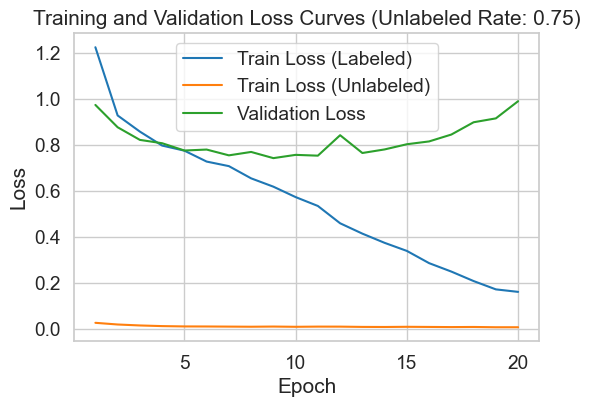

In [30]:
plot_loss_curves(ssl_history_75_nb, use_unlabeled=True, unlabeled_rate=0.75)

In [31]:
best_ssl_history_75_nb = max(ssl_history_75_nb, key=lambda x: x['val_auc'])
print(f"Best Epoch: {best_ssl_history_75_nb['epoch']} | Val AUC: {best_ssl_history_75_nb['val_auc']:.4f} | Val Acc: {best_ssl_history_75_nb['val_acc']:.4f}")

best_ssl_model_75_nb = CNN(n_channels, n_classes)
best_ssl_model_75_nb.load_state_dict(best_ssl_history_75_nb['model_state'])
test_auc = evaluate(best_ssl_model_75_nb, test_loader)
print(f"Test AUC: {test_auc:.4f}")

Best Epoch: 9 | Val AUC: 0.8997 | Val Acc: 0.7368
Test AUC: 0.8893


In [44]:
# then try with a small burn-in period of 3 epochs
num_burnin_epochs, total_epochs = 5, 20
ssl_model_75_burnin, criterion, optimizer = default_setup(lr=0.0001, l2_weight=0.0)
print(f'Starting burn-in training...')
burnin_history = train_loop_labeled(ssl_model_75_burnin, train_ssl_loader_75, val_loader, criterion, optimizer, num_epochs=num_burnin_epochs)
print(f'Burn-in training completed. Starting SSL training...')
ssl_history_75_post_burnin = train_loop_hard_pseudo_label(ssl_model_75_burnin, train_ssl_loader_75, val_loader, criterion, optimizer, num_epochs=total_epochs - num_burnin_epochs)

Starting burn-in training...


100%|██████████| 55/55 [00:01<00:00, 37.21it/s]


Epoch 1/5 | Train Loss: 1.2175 | Val Loss: 0.9688 | Val Acc: 0.6690 | Val AUC: 0.7800


100%|██████████| 55/55 [00:01<00:00, 38.05it/s]


Epoch 2/5 | Train Loss: 0.9223 | Val Loss: 0.8789 | Val Acc: 0.6750 | Val AUC: 0.8431


...

Epoch 13/15 | Train Loss Labeled: 0.2515 | Train Loss Unlabeled: 0.0084 | Val Loss: 0.8517 | Val Acc: 0.6929 | Val AUC: 0.8987


100%|██████████| 55/55 [00:04<00:00, 12.75it/s]


Epoch 14/15 | Train Loss Labeled: 0.2180 | Train Loss Unlabeled: 0.0084 | Val Loss: 0.8674 | Val Acc: 0.7198 | Val AUC: 0.8987


100%|██████████| 55/55 [00:04<00:00, 12.64it/s]


Epoch 15/15 | Train Loss Labeled: 0.1801 | Train Loss Unlabeled: 0.0076 | Val Loss: 0.8760 | Val Acc: 0.7238 | Val AUC: 0.8991


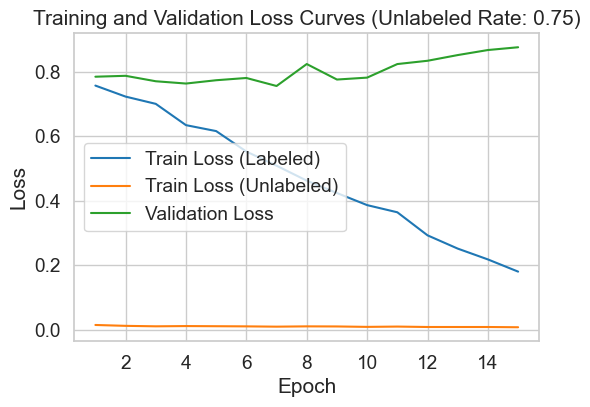

In [45]:
plot_loss_curves(ssl_history_75_post_burnin, use_unlabeled=True, unlabeled_rate=0.75)

In [46]:
best_ssl_history_75_burnin = max(ssl_history_75_post_burnin, key=lambda x: x['val_auc'])
print(f"Best Epoch: {best_ssl_history_75_burnin['epoch']} | Val AUC: {best_ssl_history_75_burnin['val_auc']:.4f} | Val Acc: {best_ssl_history_75_burnin['val_acc']:.4f}")

best_ssl_model_75_burnin = CNN(n_channels, n_classes)
best_ssl_model_75_burnin.load_state_dict(best_ssl_history_75_burnin['model_state'])
test_auc = evaluate(best_ssl_model_75_burnin, test_loader)
print(f"Test AUC: {test_auc:.4f}")

Best Epoch: 7 | Val AUC: 0.9071 | Val Acc: 0.7049
Test AUC: 0.8792
